In [2]:

import os
import re
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import praw
from bs4 import BeautifulSoup
from mastodon import Mastodon
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
from IPython.display import display

In [4]:
import requests
import pandas as pd

url = "http://127.0.0.1:8000/posts?limit=10000"
resp = requests.get(url)
resp.raise_for_status()

df_plot = pd.DataFrame(resp.json())
print(df_plot.head())

   platform        date                                               text  \
0  Mastodon  2026-05-07  AI imagines what Kareena Kapoor would look lik...   
1  Mastodon  2026-05-06  Most fashionable countries: 1. 🇮🇹 Italy 2. 🇫🇷 ...   
2  Mastodon  2026-05-06  Finnish defence giant has tech 'Australia migh...   
3  Mastodon  2026-05-06  Ranking of the most powerful countries: 1. 🇺🇸 ...   
4  Mastodon  2026-05-05  🧓 Best countries for a comfortable retirement:...   

           author  upvotes                                                url  \
0  HindustanTimes        0  https://flipboard.com/users/HindustanTimes/sta...   
1      stats_feed        0  https://zpravobot.news/ap/users/11626299762180...   
2        abcfeeds        0  https://rssfeed.media/users/abcfeeds/statuses/...   
3      stats_feed        0  https://zpravobot.news/ap/users/11626299762180...   
4      stats_feed        0  https://zpravobot.news/ap/users/11626299762180...   

   sentiment_score     conflict  \
0        

In [5]:
# Remove duplicate posts based on URL
df_plot["url"] = df_plot["url"].fillna("").astype(str).str.strip()
df_plot = df_plot[df_plot["url"] != ""].drop_duplicates(subset=["url"]).reset_index(drop=True)

In [6]:
url = "http://127.0.0.1:8000/market/prices?limit=10000"
resp = requests.get(url)
resp.raise_for_status()

oil_df = pd.DataFrame(resp.json())
print(oil_df.head())

         date benchmark   price
0  2026-05-04       WTI  109.76
1  2026-05-01     Brent  118.26
2  2026-05-01       WTI  105.38
3  2026-04-30     Brent  124.24
4  2026-04-30       WTI  108.64


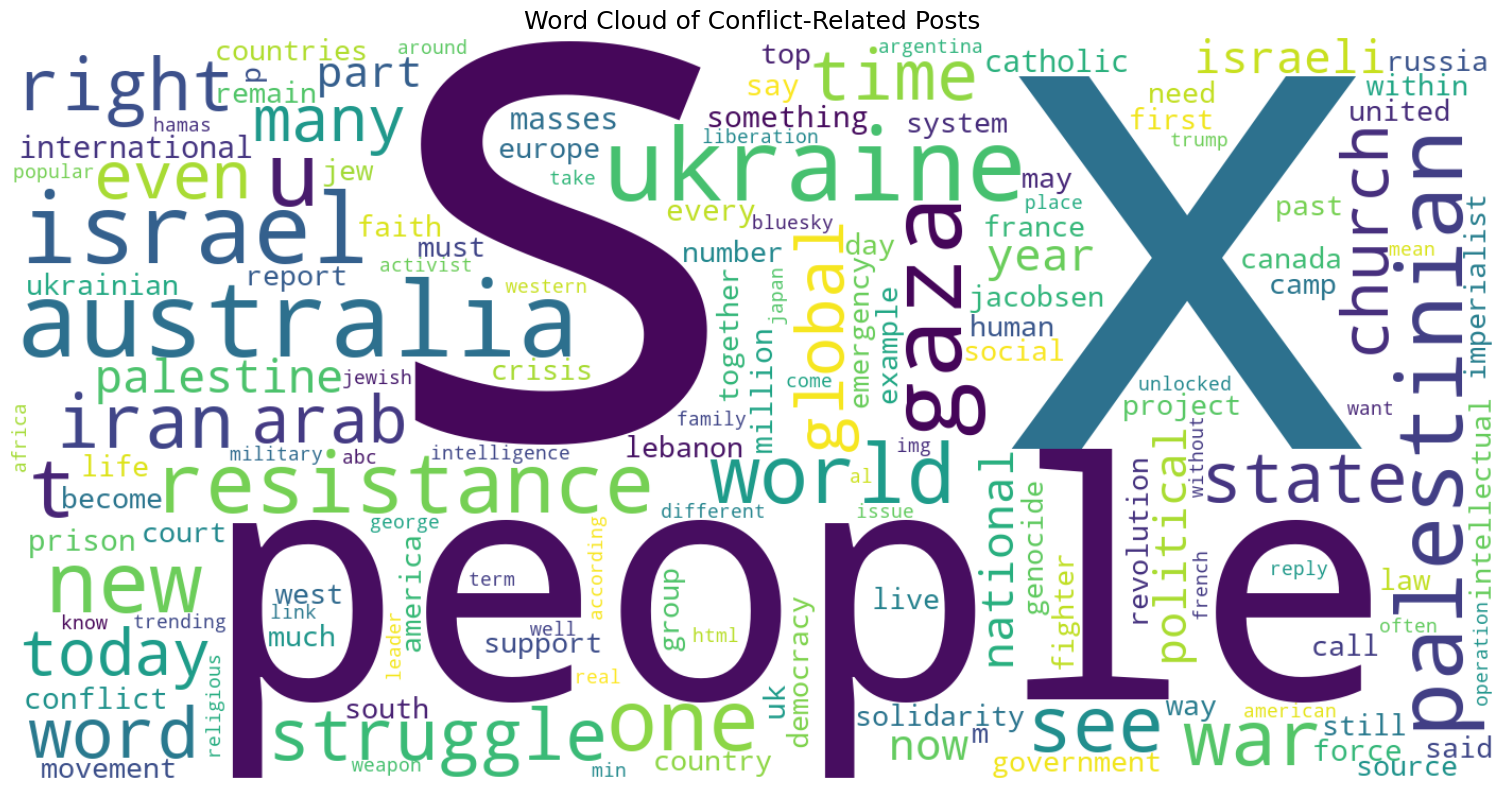

In [9]:
# Word cloud, used to display high-frequency words in conflict-related posts
def plot_wordcloud(df):
    text = " ".join(df["clean_text"].dropna().tolist())
    if not text.strip():
        print("Not enough text to generate word clouds")
        return

    stopwords = set(STOPWORDS)
    stopwords.update({
        "the", "and", "for", "with", "this", "that", "you", "are", "have",
        "from", "was", "were", "but", "they", "its", "not", "will", "your",
        "about", "what", "when", "where", "who", "how", "why", "all", "can",
        "just", "https", "http", "rt"
    })

    wc = WordCloud(
        width=1400,
        height=700,
        background_color="white",
        stopwords=stopwords,
        max_words=150,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Conflict-Related Posts", fontsize=18)
    plt.tight_layout()
    plt.show()

plot_wordcloud(df_plot)

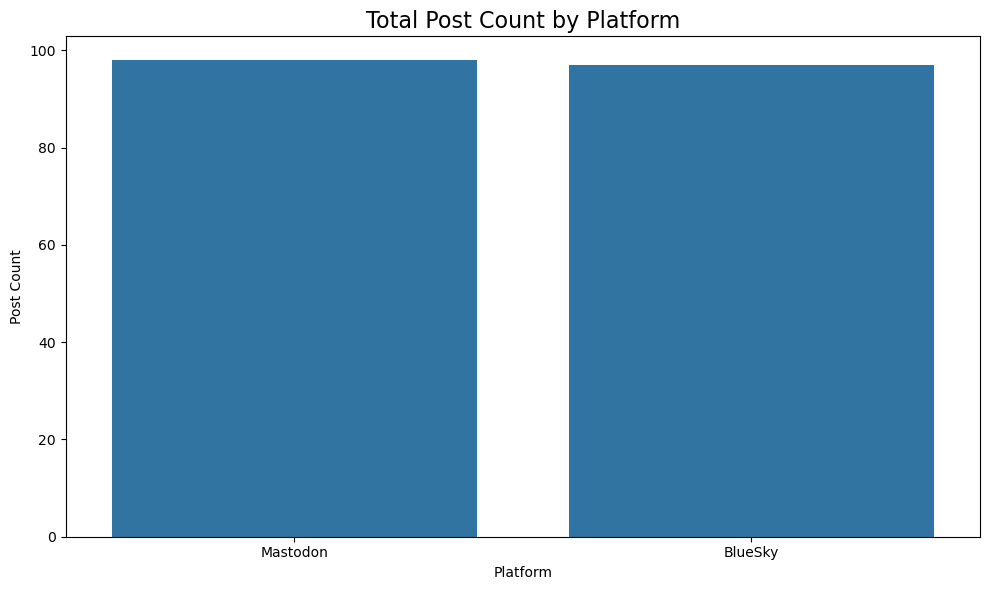

In [10]:
# Bar chart of total posts across platforms
def plot_total_posts_by_platform(df):
    plt.figure(figsize=(10, 6))
    order = df["platform"].value_counts().index
    sns.countplot(data=df, x="platform", order=order)
    plt.title("Total Post Count by Platform", fontsize=16)
    plt.xlabel("Platform")
    plt.ylabel("Post Count")
    plt.tight_layout()
    plt.show()

plot_total_posts_by_platform(df_plot)

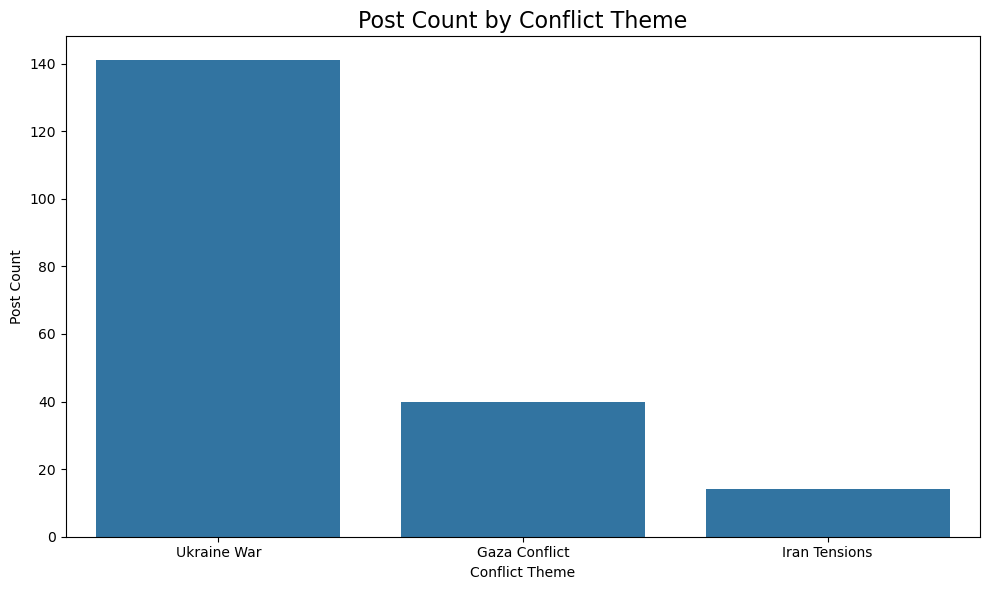

In [11]:
# Bar chart of the number of posts on different conflict topics
def plot_topic_counts(df):
    plt.figure(figsize=(10, 6))
    order = df["conflict"].value_counts().index
    sns.countplot(data=df, x="conflict", order=order)
    plt.title("Post Count by Conflict Theme", fontsize=16)
    plt.xlabel("Conflict Theme")
    plt.ylabel("Post Count")
    plt.tight_layout()
    plt.show()
    
plot_topic_counts(df_plot)

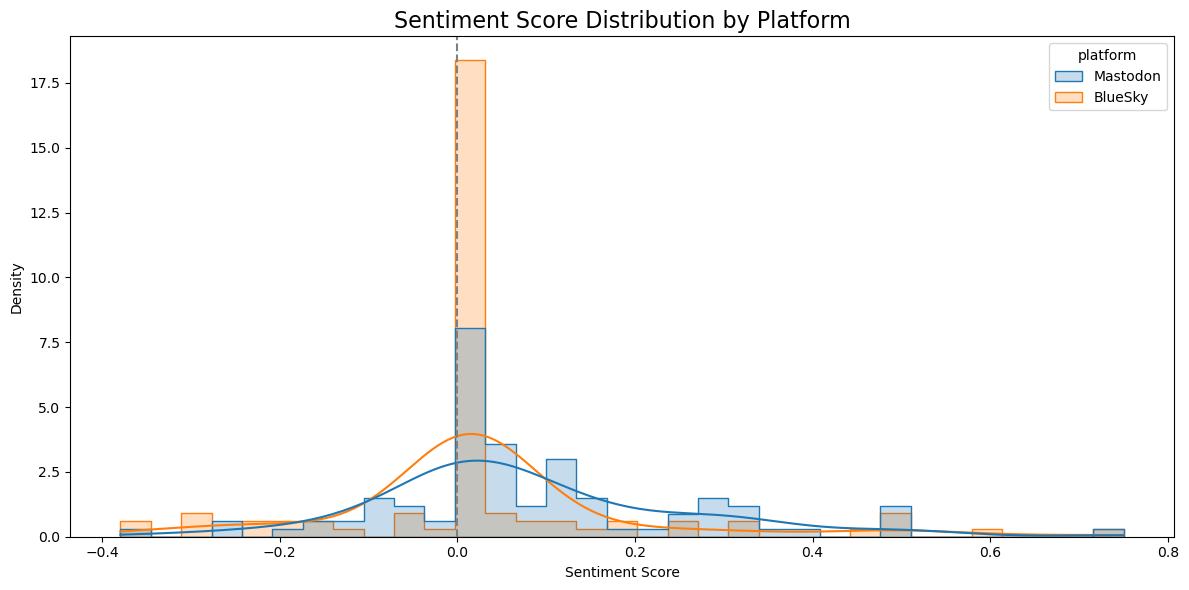

In [12]:
# Emotional Score Distribution Chart
def plot_sentiment_distribution(df):
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x="sentiment_score", hue="platform", kde=True, element="step", stat="density", common_norm=False)
    plt.axvline(0, color="gray", linestyle="--", linewidth=1.5)
    plt.title("Sentiment Score Distribution by Platform", fontsize=16)
    plt.xlabel("Sentiment Score")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

plot_sentiment_distribution(df_plot)

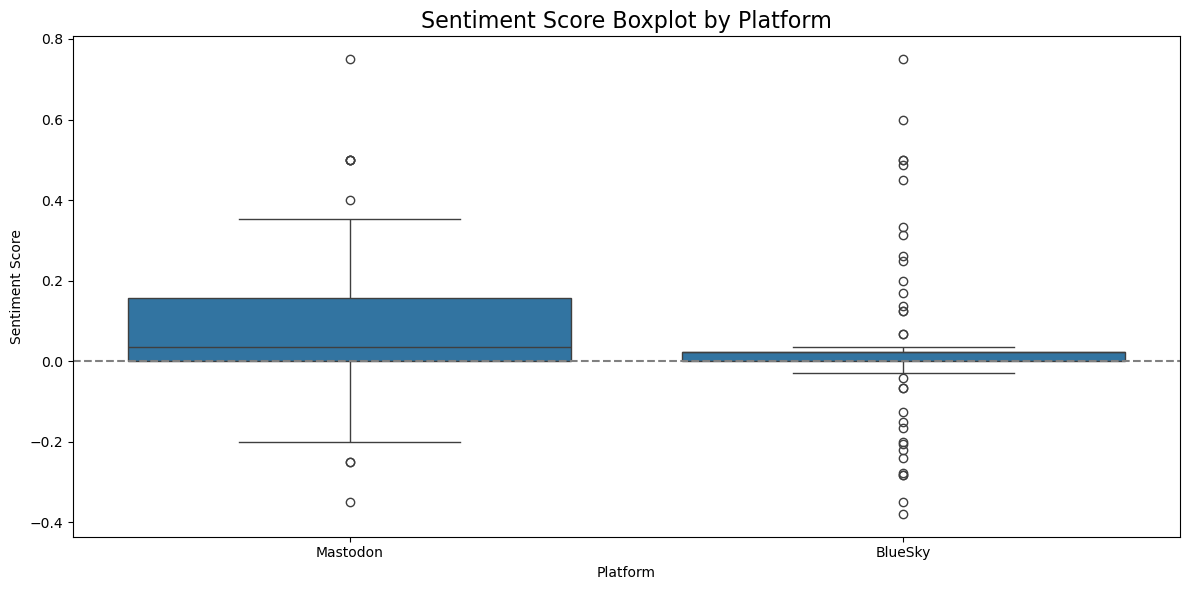

In [13]:
# Emotional Score Box Plot, Comparing the sentiment scores of posts across different social media platforms
def plot_sentiment_boxplot(df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="platform", y="sentiment_score")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)
    plt.title("Sentiment Score Boxplot by Platform", fontsize=16)
    plt.xlabel("Platform")
    plt.ylabel("Sentiment Score")
    plt.tight_layout()
    plt.show()

plot_sentiment_boxplot(df_plot)

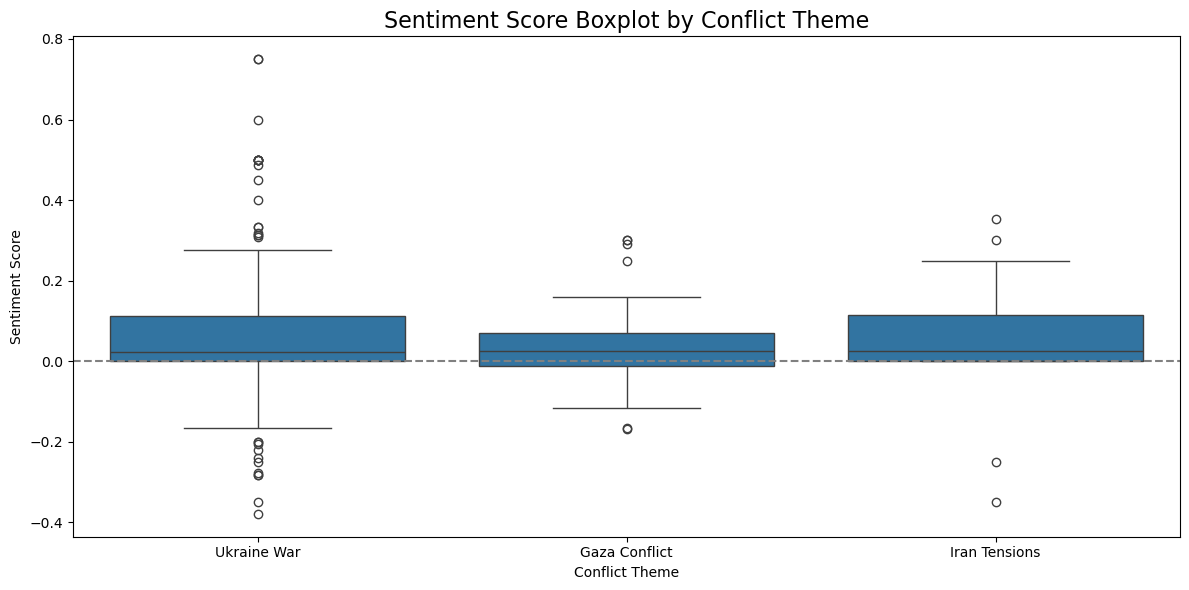

In [14]:
# Box plots of sentiment scores for different conflict themes, comparing post sentiment scores across various conflict themes
def plot_topic_sentiment_boxplot(df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="conflict", y="sentiment_score")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)
    plt.title("Sentiment Score Boxplot by Conflict Theme", fontsize=16)
    plt.xlabel("Conflict Theme")
    plt.ylabel("Sentiment Score")
    plt.tight_layout()
    plt.show()


plot_topic_sentiment_boxplot(df_plot)

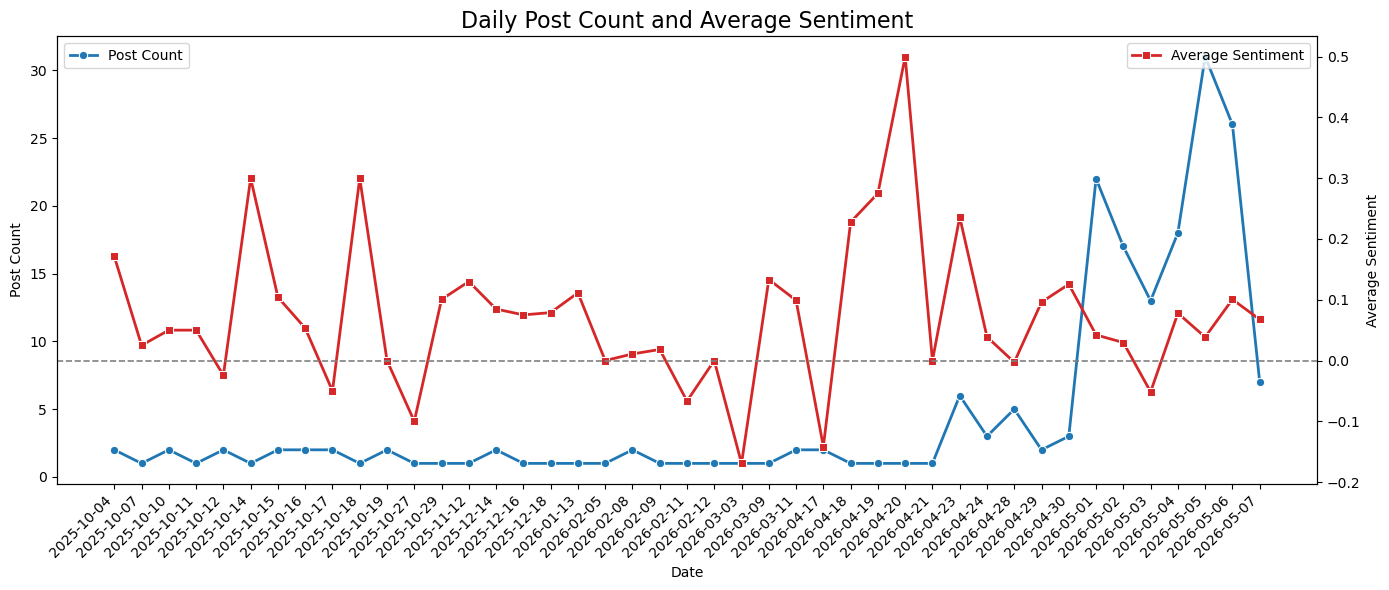

In [15]:
# Daily changes in post volume and average daily sentiment changes(dual-axis line chart)
def plot_daily_posts_and_sentiment(df):
    daily = df.groupby("date").agg(
        Post_Count=("text", "size"),
        Avg_Sentiment=("sentiment_score", "mean")
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(14, 6))
    sns.lineplot(data=daily,x="date",y="Post_Count",marker="o",color="tab:blue",linewidth=2,ax=ax1,label="Post Count")
    ax1.set_title("Daily Post Count and Average Sentiment", fontsize=16)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Post Count")

    ax2 = ax1.twinx()
    sns.lineplot(data=daily,x="date",y="Avg_Sentiment",marker="s",color="tab:red",linewidth=2,ax=ax2,label="Average Sentiment")
    ax2.axhline(0, color="gray", linestyle="--", linewidth=1.2)
    ax2.set_ylabel("Average Sentiment")

    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()

plot_daily_posts_and_sentiment(df_plot)


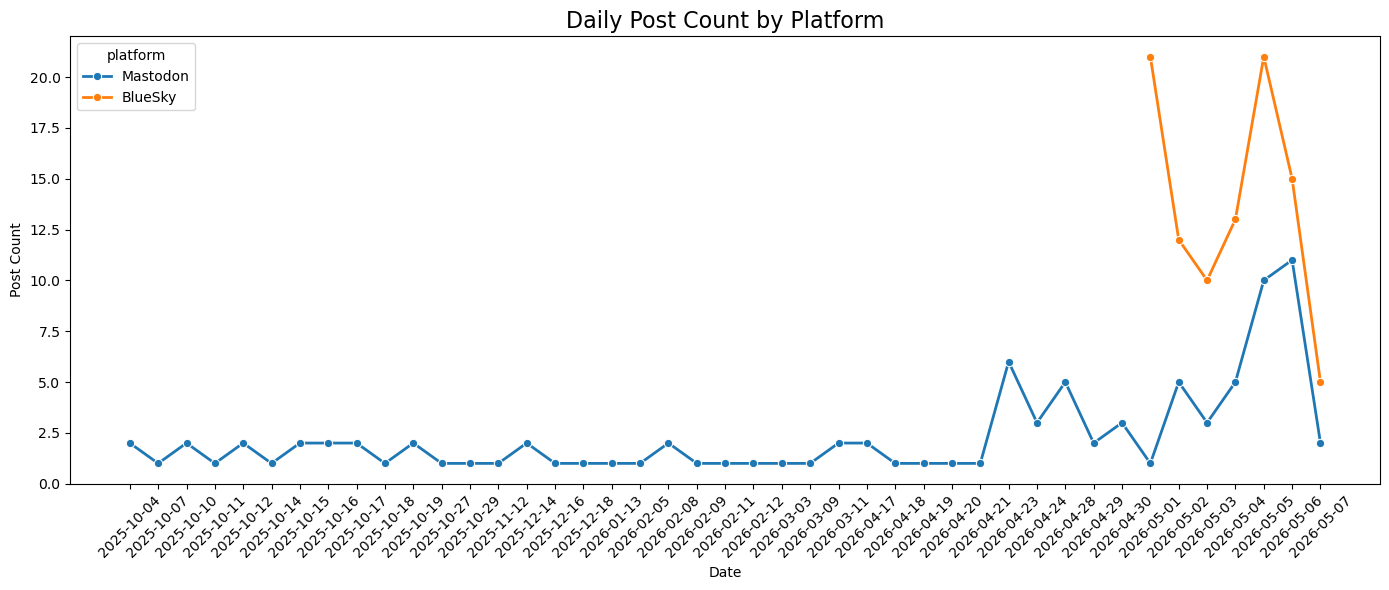

In [16]:
# Multi-line time series line chart, Daily posting trends on each platform
def plot_daily_platform_counts(df):
    vocal_data = df.groupby(["date", "platform"]).size().reset_index(name="Post_Count")

    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=vocal_data,
        x="date",
        y="Post_Count",
        hue="platform",
        marker="o",
        linewidth=2
    )
    plt.title("Daily Post Count by Platform", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_daily_platform_counts(df_plot)


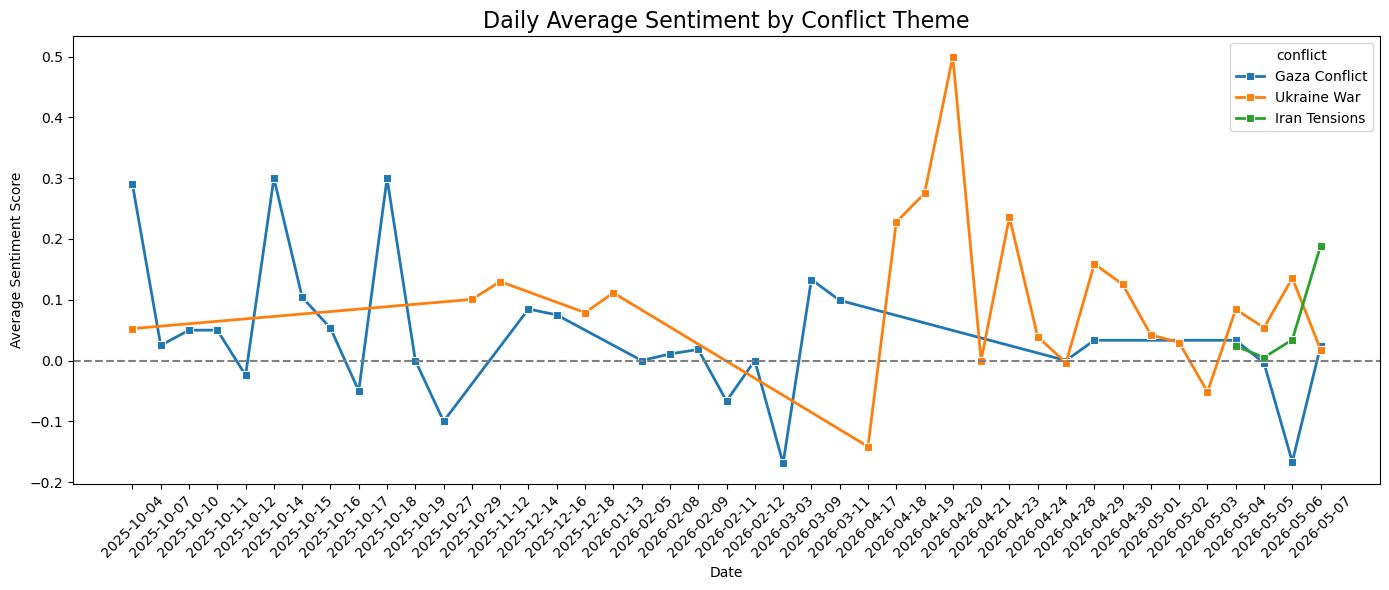

In [17]:
# Daily average sentiment trend charts for different conflict themes
def plot_daily_conflict_sentiment(df):
    sentiment_data = df.groupby(["date", "conflict"])["sentiment_score"].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=sentiment_data,
        x="date",
        y="sentiment_score",
        hue="conflict",
        marker="s",
        linewidth=2
    )
    plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)
    plt.title("Daily Average Sentiment by Conflict Theme", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Average Sentiment Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_daily_conflict_sentiment(df_plot)

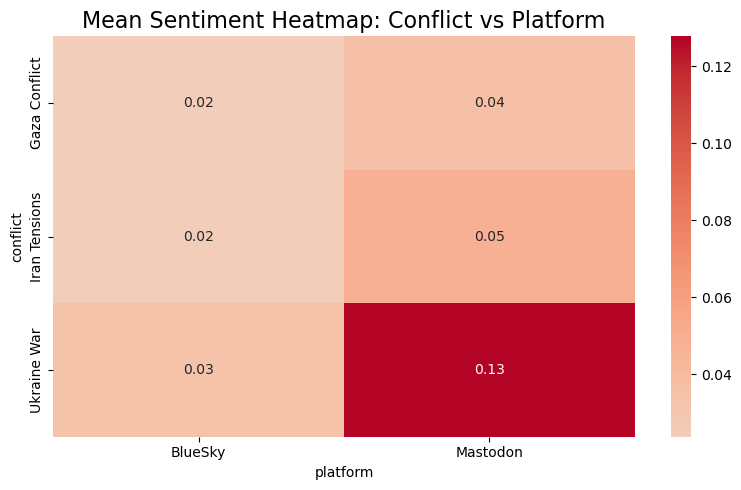

In [18]:
# Heatmap, Average sentiment scores of different conflict themes on different social media platforms
def plot_heatmap(df):
    pivot = df.pivot_table(index="conflict", columns="platform", values="sentiment_score", aggfunc="mean")
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Mean Sentiment Heatmap: Conflict vs Platform", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_heatmap(df_plot)

Loading official crude oil prices...


,date,benchmark,price
0,2026-05-04,WTI,109.76
1,2026-05-01,Brent,118.26
2,2026-05-01,WTI,105.38
3,2026-04-30,Brent,124.24
4,2026-04-30,WTI,108.64


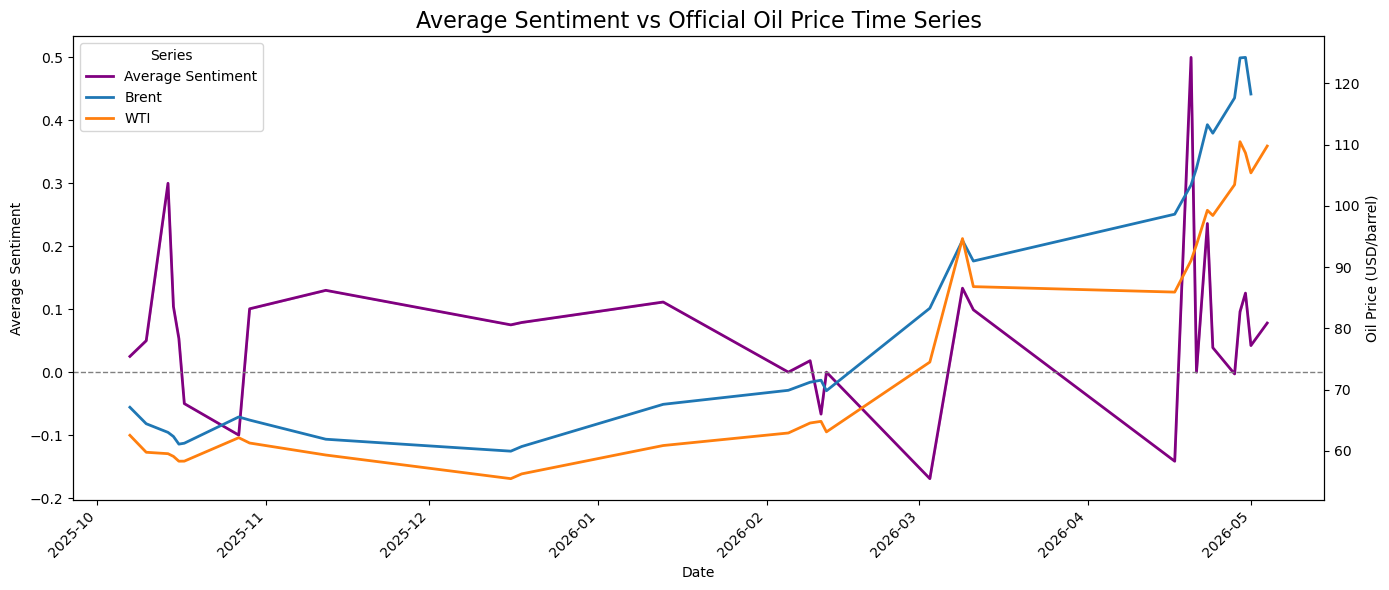

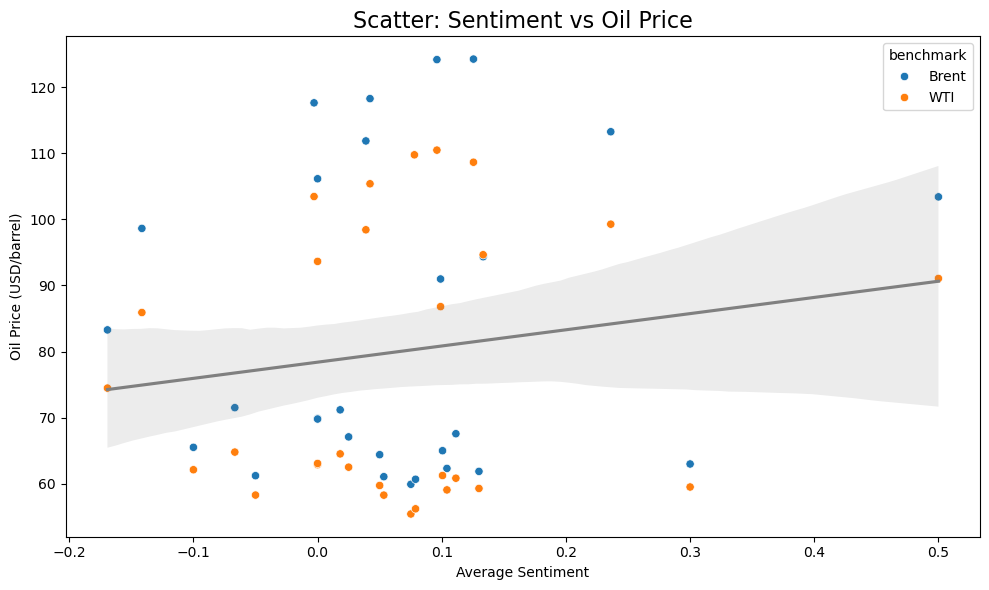

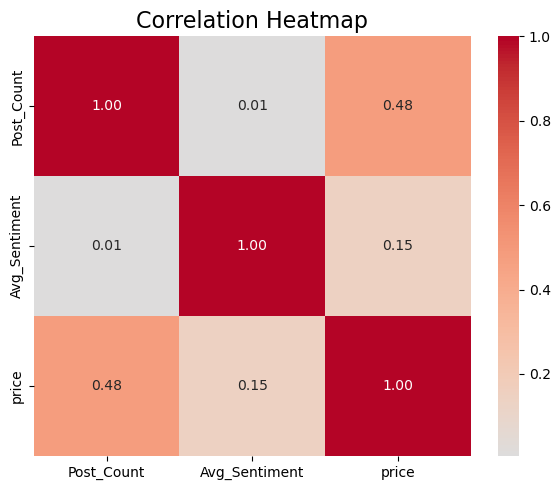

In [19]:
# The daily average sentiment score of social media posts versus the time-series variation of official crude oil prices
def plot_sentiment_vs_oil(df_daily_sentiment, oil_df):
    merged = pd.merge(df_daily_sentiment, oil_df, on="date", how="inner")

    if merged.empty:
        print("Unable to draw")
        return

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Left axis: average sentiment
    sns.lineplot(
        data=merged,
        x="date",
        y="Avg_Sentiment",
        ax=ax1,
        color="purple",
        linewidth=2,
        label="Average Sentiment"
    )
    ax1.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax1.set_ylabel("Average Sentiment")
    ax1.set_xlabel("Date")

    # Right axis: oil prices
    ax2 = ax1.twinx()
    sns.lineplot(data=merged,x="date",y="price",hue="benchmark",palette={"Brent": "tab:blue", "WTI": "tab:orange"},ax=ax2,linewidth=2,legend=False)
    ax2.set_ylabel("Oil Price (USD/barrel)")
    ax1.set_title("Average Sentiment vs Official Oil Price Time Series", fontsize=16)

    # Merge legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    # Remove duplicate title-like label if needed
 # Merge legends from both axes
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color="purple", lw=2),Line2D([0], [0], color="tab:blue", lw=2),Line2D([0], [0], color="tab:orange", lw=2),]
    ax1.legend(custom_lines,["Average Sentiment", "Brent", "WTI"],loc="upper left",title="Series")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


# Scatter plot of the relationship between sentiment and oil prices
def plot_sentiment_price_scatter(df_daily_sentiment, oil_df):
    merged = pd.merge(df_daily_sentiment, oil_df, on="date", how="inner")
    if merged.empty:
        print("Unable to draw")
        return

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged, x="Avg_Sentiment", y="price", hue="benchmark")
    sns.regplot(data=merged, x="Avg_Sentiment", y="price", scatter=False, color="gray")
    plt.title("Scatter: Sentiment vs Oil Price", fontsize=16)
    plt.xlabel("Average Sentiment")
    plt.ylabel("Oil Price (USD/barrel)")
    plt.tight_layout()
    plt.show()


# Correlation coefficient heatmap
def plot_correlation_heatmap(df_daily_sentiment, oil_df):
    merged = pd.merge(df_daily_sentiment, oil_df, on="date", how="inner")
    if merged.empty:
        print("Unable to draw")
        return

    corr_df = merged[["Post_Count", "Avg_Sentiment", "price"]].copy()
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation Heatmap", fontsize=16)
    plt.tight_layout()
    plt.show()


print("Loading official crude oil prices...")
oil_df = oil_df

# Check whether the oil price data has been successfully retrieved; if data is available, display the first few rows
if not oil_df.empty:
    display(oil_df.head())
else:
    print("Official fuel price data is not available.")

# Standardise the date format in the social media dataset first
df_plot["date"] = pd.to_datetime(df_plot["date"], errors="coerce").dt.normalize()
df_plot = df_plot.dropna(subset=["date"]).copy()

# Aggregate data by date, calculate the number of posts per day and the average sentiment score
daily_sentiment = df_plot.groupby("date").agg(
    Post_Count=("text", "size"),
    Avg_Sentiment=("sentiment_score", "mean")
).reset_index()

# Standardise the date format in the daily sentiment table
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"], errors="coerce").dt.normalize()
daily_sentiment = daily_sentiment.dropna(subset=["date"]).copy()

# If official oil price data is available, retain the Brent and WTI prices
if not oil_df.empty:
    oil_for_plot = oil_df[oil_df["benchmark"].isin(["Brent", "WTI"])].copy()
    oil_for_plot["date"] = pd.to_datetime(oil_for_plot["date"], errors="coerce").dt.normalize()
    oil_for_plot = oil_for_plot.dropna(subset=["date"]).sort_values("date")

    # Plot graph
    plot_sentiment_vs_oil(daily_sentiment, oil_for_plot)
    plot_sentiment_price_scatter(daily_sentiment, oil_for_plot)
    plot_correlation_heatmap(daily_sentiment, oil_for_plot)